# Import Libraries

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Load the Dataset

In [3]:
#Load the Dataset
df=pd.read_csv("Downloads/Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning

In [4]:
#To check overview about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#Total Charges is object because we have some customers whose tenure is 0 that's why  their Total ccharge value is empty 
#so we replace that empty space with 0 and then convert the datatype into float

df['TotalCharges']=df['TotalCharges'].replace(" ","0")
df['TotalCharges']=df['TotalCharges'].astype('float')

In [6]:
#Now let's check the datatype of TotalCharges again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
#Now check that is there any empty value (Nan) value or not
df.isnull().sum().sum()

np.int64(0)

In [8]:
#To check some descriptive statistics of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
#To check is there any duplicates in our data or not (overall duplicate check)
df.duplicated().sum()

np.int64(0)

In [10]:
#To check duplicate based on unique values  in our dataset (it is like primary key)
df['customerID'].duplicated().sum()

np.int64(0)

In [11]:
#As 'SeniorCitizen' is an INT datatype column but it represent cateogry (YES OR NO) in the form of 0 & 1 so we transform it and change it into object
#make a fun
def conv(value):
    if value==1:
        return "Yes"
    else:
        return "No"

#Apply fun on column
df['SeniorCitizen']=df['SeniorCitizen'].apply(conv)

In [12]:
#Now check the dataset that the values are applied or not
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

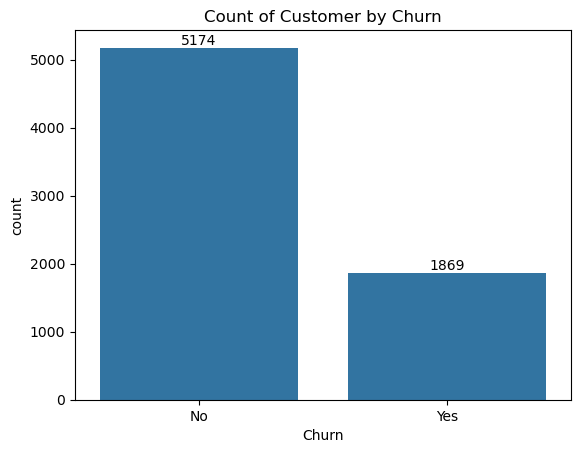

In [13]:
#How much customers and churn out or not means they leaves or not   (Churn=Yes(1) means he/she leaves & Churn=No(0) he/she doesn't leave)
ax=sns.countplot(x='Churn', data=df)

#To show data labels on countplot
ax.bar_label(ax.containers[0])

plt.title('Count of Customer by Churn')
plt.show()

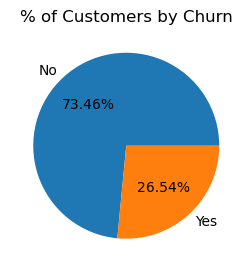

In [14]:
#To check its percentage 
plt.figure(figsize=(3,4))
gb=df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'], labels=gb.index, autopct="%1.2f%%")
plt.title('% of Customers by Churn')
plt.show()

From the given piechart we conclude that 26.54% of our customers are churned out

### Now let's find the reason behind it that why customers churned 

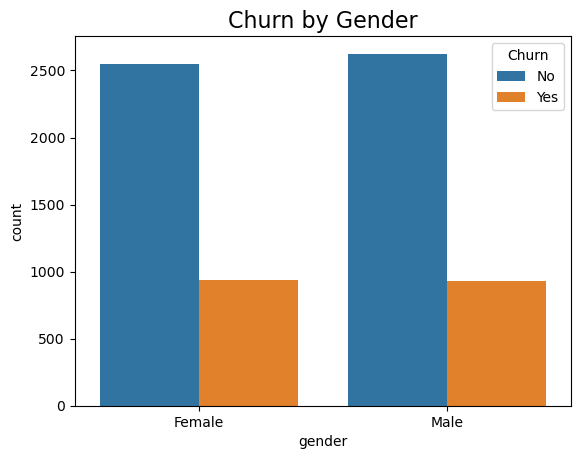

In [15]:
#Now check how much male & female churn out
sns.countplot(x='gender', data=df, hue='Churn')
plt.title('Churn by Gender',fontsize=16)
plt.show()

As we can see that the churning out is not gender based 

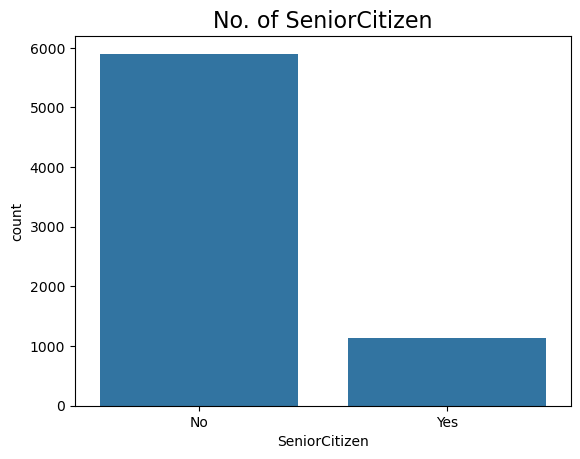

In [16]:
#We check how much of our customers are SeniorCitizens
sns.countplot(x='SeniorCitizen', data=df) 
plt.title('No. of SeniorCitizen',fontsize=16) 
plt.show()

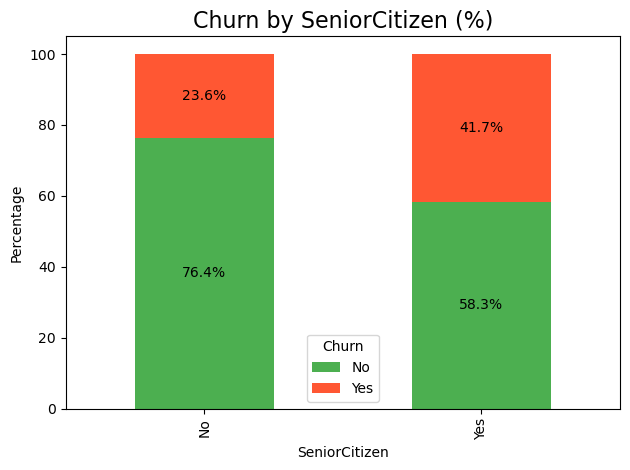

In [17]:
#Check the % of Churnout based on SeniorCitizen

# Step 1: Create crosstab
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Step 2: Convert to percentage (row-wise)
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# Step 3: Plot stacked bar chart
ax = ct_percent.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF5733']   )

plt.title('Churn by SeniorCitizen (%)', fontsize=16)
plt.ylabel('Percentage')
plt.xlabel('SeniorCitizen')

# Step 4: Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.legend(title='Churn')
plt.tight_layout()
plt.show()

As we can see we have less SeniorCitizens in our data. But those who are SeniorCitizens most of them churned out.

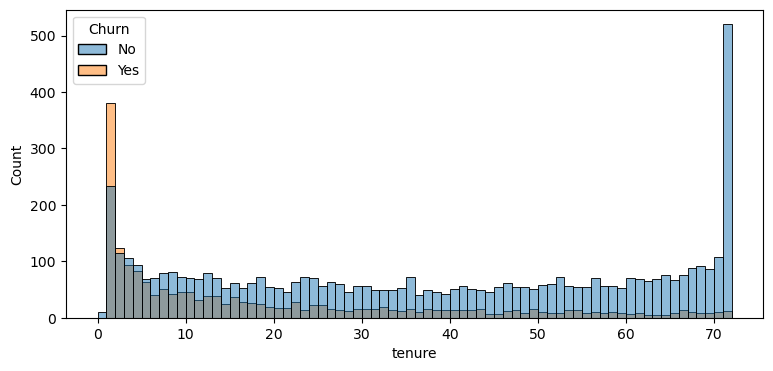

In [19]:
#Now we check churnedout on the basis of tenure
plt.figure(figsize=(9,4))
sns.histplot(x='tenure', data=df, bins=72, hue='Churn')
plt.show()

From the above histplot we conclude that people who have used our services for a long time have stayed and people who have used our
services 1 and 2 month have churned out

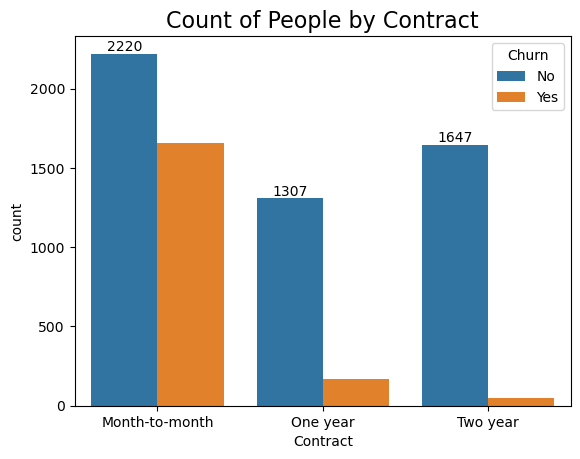

In [22]:
#Now we see count of people we have according to Contract
ax= sns.countplot(x='Contract', data=df , hue='Churn') 
ax.bar_label(ax.containers[0])
plt.title('Count of People by Contract',fontsize=16) 
plt.show()

As we can see that most of the people who are on short contract with us (Month-to-Month) have churned out the most.
So , we should design techniques that grabs long-term customers 

In [23]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

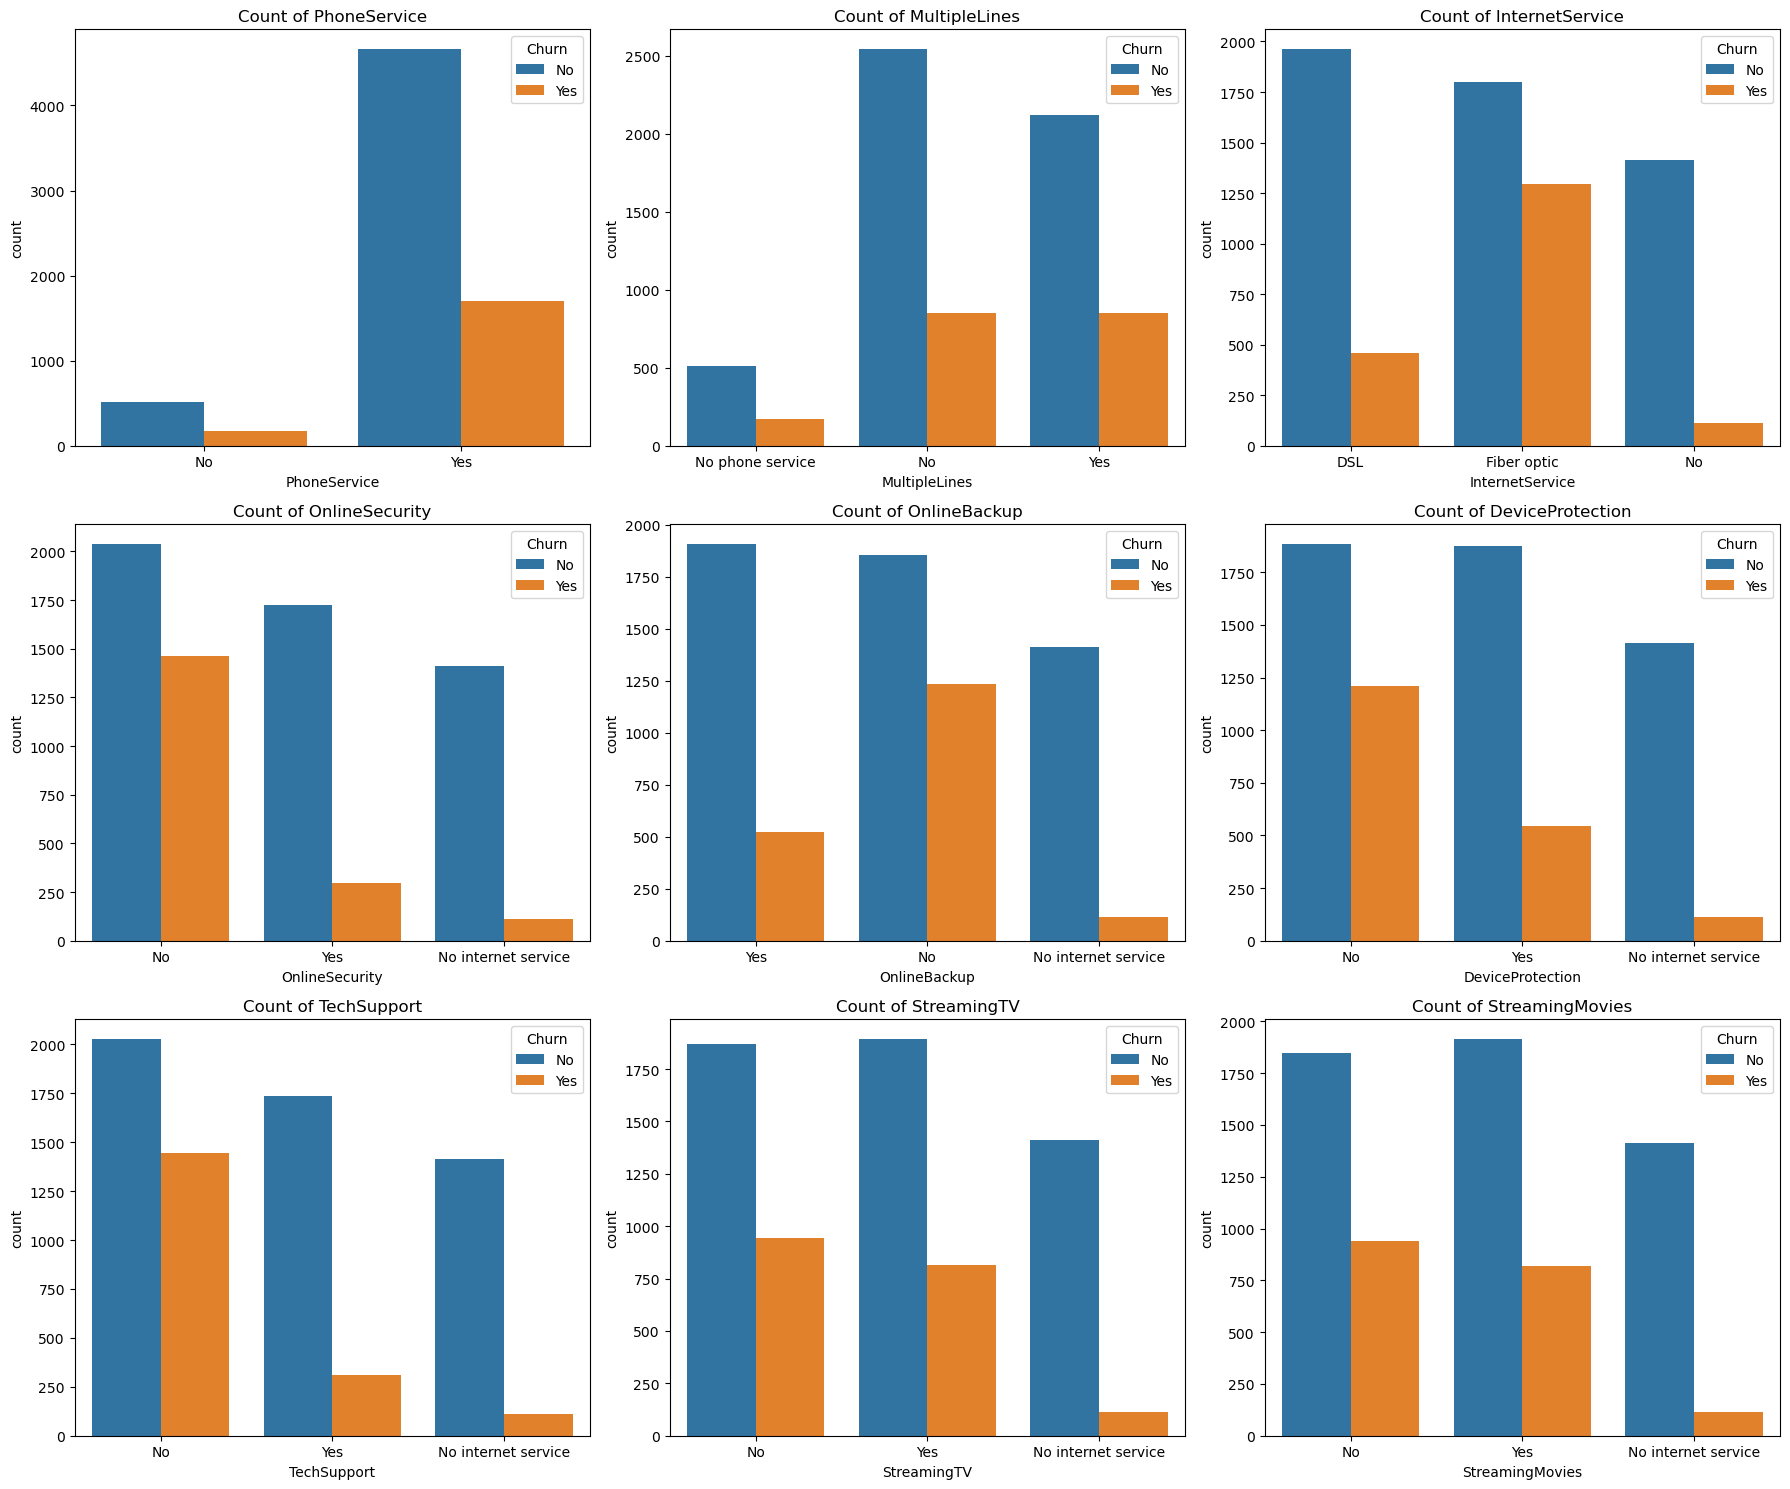

In [28]:
#Now we see the counplots of Customer Services
# List of columns
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# Create subplot grid (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through columns and create countplot
for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, ax=axes[i], hue=df['Churn'])
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=0)

# Adjust layout
plt.tight_layout()
plt.show()

### Overall Business Findings

* Customers without internet-related support services (Security, Backup, Tech Support, Device Protection) are more likely to churn.

* Fiber optic users show higher churn, which may indicate pricing or service quality concerns.

* Support and security services are strong retention drivers.

* Basic services like phone service or streaming have limited impact on churn.


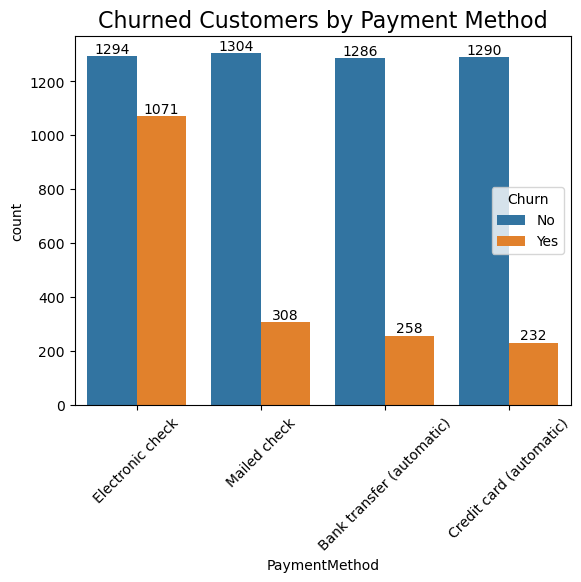

In [33]:
#Now we check churned customers based on payement method
ax= sns.countplot(x='PaymentMethod', data=df , hue='Churn') 
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churned Customers by Payment Method',fontsize=16) 
plt.xticks(rotation=45)
plt.show()

Most customers are likely to churn when they pay through Electronic check